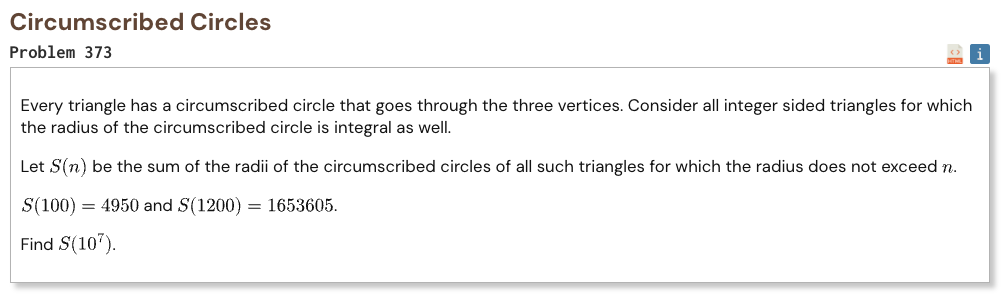

## Initial approach

* count triangles separately for each possible integer circumradius
* the number of triangles depends only on prime exponents in the radius
* only prime factors that leave remainder 1 when divided by 4 affect the count
* build a smallest prime factor table to factor every radius quickly
* combine the relevant exponents with the triangle counting rule
* multiply the number of triangles by the current radius
* add all contributions up to ten million

In [1]:
from array import array

def build_spf(limit):
    spf = array("I", [0]) * (limit + 1)
    primes = array("I")

    for i in range(2, limit + 1):
        if spf[i] == 0:
            spf[i] = i
            primes.append(i)

        smallest = spf[i]

        for p in primes:
            value = i * p

            if value > limit:
                break

            spf[value] = p

            if p == smallest:
                break

    return spf

def S(limit):
    spf = build_spf(limit)

    first = [0] * 25
    second = [0] * 25
    third = [0] * 25

    for exponent in range(25):
        first[exponent] = 3 * exponent * exponent + 3 * exponent + 1
        second[exponent] = 2 * exponent + 1
        third[exponent] = 2 * (exponent // 2) + 1

    total = 0

    for radius in range(1, limit + 1):
        value = radius
        product_1 = 1
        product_2 = 1
        product_3 = 1

        while value > 1:
            prime = spf[value]
            exponent = 0

            while value % prime == 0:
                value //= prime
                exponent += 1

            if prime % 4 == 1:
                product_1 *= first[exponent]
                product_2 *= second[exponent]
                product_3 *= third[exponent]

        if product_1 == 1:
            continue

        triangle_count = (
            2 * product_1
            - 3 * product_2
            + 3 * product_3
            - 2
        ) // 6

        total += radius * triangle_count

    return total

assert S(100) == 4950
assert S(1200) == 1653605

In [2]:
%%time
result = S(10_000_000)
print("Result:", result)

Result: 727227472448913
CPU times: user 5.59 s, sys: 61.2 ms, total: 5.65 s
Wall time: 5.78 s
